## 02 - Train and Infer GeoRT Student

Colab runner for the theory-aligned GeoRT student.

The source code now trains the student with separated supervision:

- `D_cm/C_cm`: metric branch, GT priority then DMD3C or compatible fused metric output;
- `R_G/C_G`: geometry branch, fused geometry if available, otherwise Depth Anything raw as structure-only fallback;
- student outputs `D_full/C_full` and internal `D_1_4/C_1_4`;
- inference uses only RGB, sparse depth, mask, ray/UV, and intrinsics.


In [4]:
from pathlib import Path
import os
import sys

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = os.environ.get(
        'GEORT_PROJECT_DIR',
        '/content/drive/MyDrive/DEPTH-FUSION | Workspace/monocular_sparse_fusion/GeoRT',
    )
    PROJECT_ROOT = Path(PROJECT_DIR)
except Exception:
    PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = 'configs/geort_student_s.yaml'
REFRESH_SPLITS = False
TRAIN_COUNT = 800

RUN_TRAIN = True
RUN_INFER_VAL = True
RUN_INFER_TEST = True
CHECKPOINT_FOR_INFER = None

print('PROJECT_ROOT =', PROJECT_ROOT)


Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/DEPTH-FUSION | Workspace/monocular_sparse_fusion/GeoRT


In [5]:
%pip install -q -r requirements.txt


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 732.3/732.3 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.7/452.7 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 124.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 104.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [6]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np

from src.dataset import KITTIDepthCompletionDataset
from src.prepare_depth_selection import build_depth_selection_splits
from src.utils import load_project_config

cfg, paths = load_project_config(CONFIG_PATH)

if REFRESH_SPLITS:
    counts = build_depth_selection_splits(paths['data_root'], train_count=TRAIN_COUNT)
    print('Refreshed splits:', counts)
else:
    print('Using existing split files. Set REFRESH_SPLITS=True only if you want to rebuild them.')

print(json.dumps({k: paths[k] for k in ['project_root', 'data_root', 'split_root', 'teacher_root', 'student_root']}, indent=2))
print('image_size =', cfg['data']['image_size'])
print('loss =', json.dumps(cfg['loss'], indent=2))
print('schedule =', cfg['schedule'])


Using existing split files. Set REFRESH_SPLITS=True only if you want to rebuild them.
{
  "project_root": "/content/drive/MyDrive/DEPTH-FUSION | Workspace/monocular_sparse_fusion/GeoRT",
  "data_root": "/content/drive/MyDrive/DEPTH-FUSION | Workspace/monocular_sparse_fusion/GeoRT/data/depth_selection",
  "split_root": "/content/drive/MyDrive/DEPTH-FUSION | Workspace/monocular_sparse_fusion/GeoRT/data/depth_selection/splits",
  "teacher_root": "/content/drive/MyDrive/DEPTH-FUSION | Workspace/monocular_sparse_fusion/GeoRT/teacher_outputs",
  "student_root": "/content/drive/MyDrive/DEPTH-FUSION | Workspace/monocular_sparse_fusion/GeoRT/student_outputs"
}
image_size = [352, 1216]
loss = {
  "lambda_gt": 1.0,
  "lambda_S": 1.0,
  "lambda_cm": 0.4,
  "lambda_aux": 0.2,
  "lambda_range": 0.15,
  "lambda_gt_1_4": 1.0,
  "lambda_cm_1_4": 1.0,
  "lambda_ssi": 0.03,
  "lambda_ord": 0.03,
  "lambda_C": 0.05,
  "lambda_C_calib": 0.5,
  "lambda_E": 0.01,
  "lambda_s": 0.01,
  "use_teacher_conf": tru

metric_coarse/train            0
metric_coarse/val              200
fused/train                    0
fused/val                      200
dmd3c/train                    0
dmd3c/val                      200
geometry_fused/train           0
geometry_fused/val             200
depth_anything/train_raw       0
depth_anything/val_raw         200
train samples: 800
sample: 2011_09_26_drive_0002_sync_image_0000000005_image_02
rgb/sparse/gt/D_cm/R_G: torch.Size([3, 352, 1216]) torch.Size([1, 352, 1216]) torch.Size([1, 352, 1216]) torch.Size([1, 352, 1216]) torch.Size([1, 352, 1216])


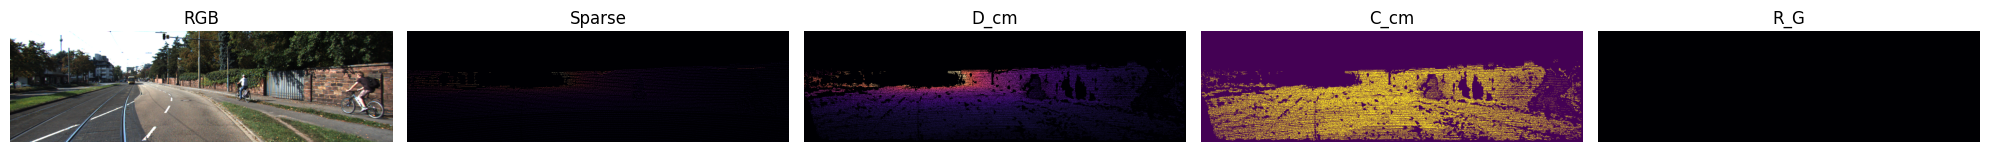

In [7]:
def count_npz(rel):
    return len(list((Path(paths['teacher_root']) / rel).glob('*.npz')))

for rel in [
    'metric_coarse/train', 'metric_coarse/val',
    'fused/train', 'fused/val',
    'dmd3c/train', 'dmd3c/val',
    'geometry_fused/train', 'geometry_fused/val',
    'depth_anything/train_raw', 'depth_anything/val_raw',
]:
    print(f'{rel:30s}', count_npz(rel))

train_ds = KITTIDepthCompletionDataset(
    paths['data_root'], paths['split_root'], paths['train_split'], 'train',
    image_size=tuple(cfg['data']['image_size']),
    output_scale=int(cfg['data']['output_scale']),
    depth_scale=float(cfg['data'].get('depth_scale', 256.0)),
    teacher_root=paths['teacher_root'],
    load_teacher=True,
    load_geometry=True,
    return_tensors=True,
)
print('train samples:', len(train_ds))
sample = train_ds[0]
print('sample:', sample['sample_id'])
print('rgb/sparse/gt/D_cm/R_G:', sample['rgb'].shape, sample['sparse'].shape, sample['gt'].shape, sample['D_cm'].shape, sample['R_G'].shape)

fig, ax = plt.subplots(1, 5, figsize=(20, 4))
ax[0].imshow(sample['rgb'].permute(1, 2, 0).numpy()); ax[0].set_title('RGB')
ax[1].imshow(sample['sparse'][0].numpy(), cmap='magma'); ax[1].set_title('Sparse')
ax[2].imshow(sample['D_cm'][0].numpy(), cmap='magma'); ax[2].set_title('D_cm')
ax[3].imshow(sample['C_cm'][0].numpy(), cmap='viridis', vmin=0, vmax=1); ax[3].set_title('C_cm')
ax[4].imshow(sample['R_G'][0].numpy(), cmap='magma'); ax[4].set_title('R_G')
for a in ax:
    a.axis('off')
plt.tight_layout()


In [8]:
if RUN_TRAIN:
    subprocess.run([sys.executable, '-m', 'src.train_student', '--config', CONFIG_PATH], check=True)
else:
    print('Skipping training.')


In [9]:
best_ckpt = Path(CHECKPOINT_FOR_INFER) if CHECKPOINT_FOR_INFER else Path(paths['student_root']) / 'checkpoints' / 'best.pth'
last_ckpt = Path(paths['student_root']) / 'checkpoints' / 'last.pth'
if not best_ckpt.exists() and last_ckpt.exists():
    best_ckpt = last_ckpt
print('checkpoint:', best_ckpt, best_ckpt.exists())


checkpoint: /content/drive/MyDrive/DEPTH-FUSION | Workspace/monocular_sparse_fusion/GeoRT/student_outputs/checkpoints/best.pth True


In [12]:
if best_ckpt.exists() and RUN_INFER_VAL:
    subprocess.run([sys.executable, '-m', 'src.infer_student', '--config', CONFIG_PATH, '--checkpoint', str(best_ckpt), '--split', 'val'], check=True)
if best_ckpt.exists() and RUN_INFER_TEST:
    subprocess.run([sys.executable, '-m', 'src.infer_student', '--config', CONFIG_PATH, '--checkpoint', str(best_ckpt), '--split', 'test'], check=True)


keys: ['D_full', 'C_full', 'D_1_4', 'C_1_4', 'D_c', 'C']


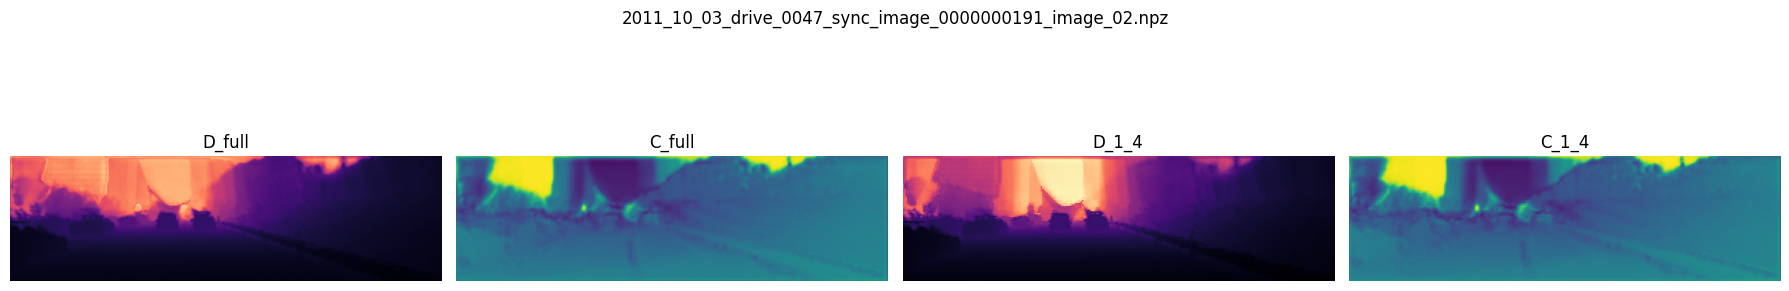

In [13]:
pred_dir = Path(paths['student_root']) / 'val_predictions'
npz_files = sorted(pred_dir.glob('*.npz'))
if not npz_files:
    print('No validation predictions found yet:', pred_dir)
else:
    pred_file = npz_files[0]
    with np.load(pred_file) as data:
        print('keys:', data.files)
        D_full = data['D_full']
        C_full = data['C_full']
        D_1_4 = data['D_1_4']
        C_1_4 = data['C_1_4']
    fig, ax = plt.subplots(1, 4, figsize=(18, 4))
    ax[0].imshow(D_full, cmap='magma'); ax[0].set_title('D_full')
    ax[1].imshow(C_full, cmap='viridis', vmin=0, vmax=1); ax[1].set_title('C_full')
    ax[2].imshow(D_1_4, cmap='magma'); ax[2].set_title('D_1_4')
    ax[3].imshow(C_1_4, cmap='viridis', vmin=0, vmax=1); ax[3].set_title('C_1_4')
    for a in ax:
        a.axis('off')
    plt.suptitle(pred_file.name)
    plt.tight_layout()
